# 0. starfold, the walkthrough

This notebook is the front door to the package. It takes you from
"I have a matrix of numbers" to "I have a clustering I trust, with
audit panels next to it, and I know what each piece of the pipeline
is doing". Run the cells top to bottom; you do not need to have read
the source first.

**What you will meet, in order.**

1. A simple synthetic dataset to cluster.
2. Input validation and sample-size-aware defaults.
3. The one-line `pipeline.fit(X)` and what comes back.
4. The four core building blocks (UMAP / t-SNE / PCA, HDBSCAN, Optuna search, trustworthiness).
5. The noise baseline and the global credibility test.
6. Robustness diagnostics (chunked silhouette, subsample stability).
7. Hierarchical refinement (merge suggestions, sub-cluster refit).
8. Input-uncertainty handling (post-hoc Monte Carlo and uncertainty-aware fit).
9. Saving, reloading, and one-line audit dashboards.

Every public function in `starfold.__all__` is demonstrated at least
once. We use small, reproducible parameters so the notebook runs in
a few minutes on a laptop; production budgets are noted in prose.

## Set-up

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs

import starfold as sf

FIGURE_DIR = Path("figures") / "tutorial_00_walkthrough"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"starfold {sf.__version__}")
print(f"public API: {len(sf.__all__)} symbols")
print(f"GPU backend importable: {sf.cuml_is_importable()}")

starfold 0.0.1
public API: 30 symbols
GPU backend importable: False


`sf.cuml_is_importable()` is a one-call check for the RAPIDS GPU
backend. The pipeline defaults to `engine="auto"` and silently uses
the CPU path when cuml is not present.

## §1. The dataset

We start with a `(600, 5)` feature matrix drawn from three Gaussian
clumps that overlap mildly along most axes. Five dimensions is
enough that visual inspection of any two raw features is misleading
(clusters look smeared) but few enough that we can build intuition
along the way.

In [2]:
X, y_truth = make_blobs(
    n_samples=600,
    n_features=5,
    centers=3,
    cluster_std=1.6,
    random_state=0,
)
print(f"X shape:     {X.shape}")
print(f"feature ranges (min..max per column):")
for i, (lo, hi) in enumerate(zip(X.min(axis=0), X.max(axis=0))):
    print(f"  col {i}:  {lo:+.2f} .. {hi:+.2f}")

X shape:     (600, 5)
feature ranges (min..max per column):
  col 0:  -3.20 .. +9.77
  col 1:  -4.95 .. +9.27
  col 2:  -3.57 .. +12.41
  col 3:  -3.03 .. +13.93
  col 4:  -13.47 .. +1.81


`y_truth` is the ground-truth label vector. The pipeline never sees
it; we keep it only to colour reference plots at the end.

### What the raw data looks like

Two pairwise-feature scatters of the same 600 samples, coloured by
the *true* component. Adjacent panels disagree on how separable the
clusters look. This is exactly why dimensionality reduction earns
its place.

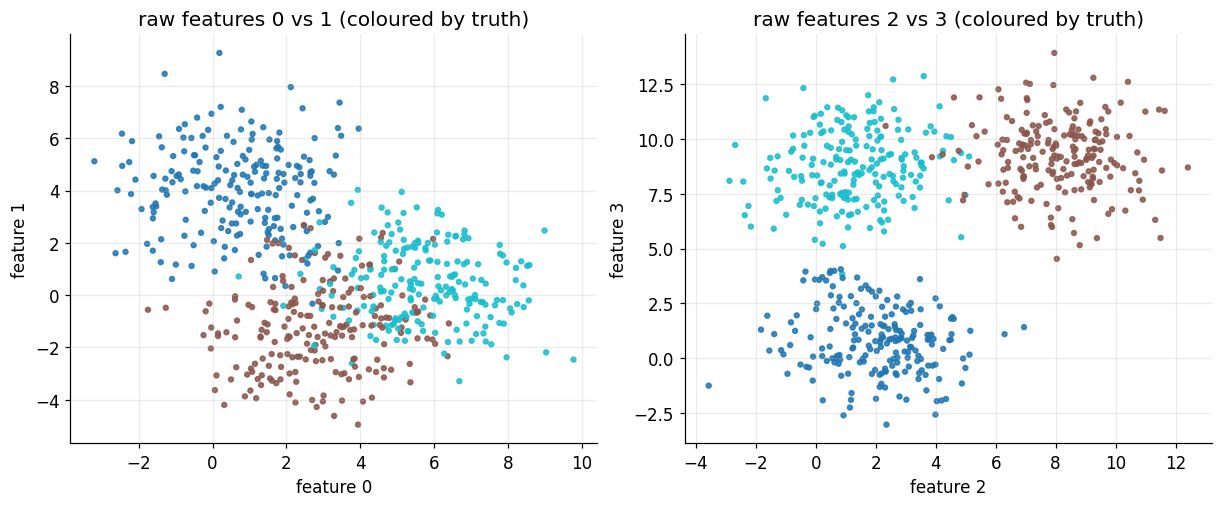

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.5), constrained_layout=True)
for ax, (i, j) in zip(axes, [(0, 1), (2, 3)]):
    ax.scatter(X[:, i], X[:, j], c=y_truth, cmap="tab10", s=10, alpha=0.85)
    ax.set_xlabel(f"feature {i}")
    ax.set_ylabel(f"feature {j}")
    ax.set_title(f"raw features {i} vs {j} (coloured by truth)")
fig.savefig(FIGURE_DIR / "01_raw_data.png")
plt.show()

## §2. Before fitting: input validation and budgets

Three small helpers run before any expensive work.

### `validate_input_matrix`

Catches the obvious mistakes (`X` is not 2-D, has NaN or inf, has a
constant column, or has fewer rows than `n_neighbors`). The
pipeline calls this internally; you can also call it yourself to
get a clear error before paying for a fit.

In [4]:
sf.validate_input_matrix(X, n_neighbors=15)
print("input matrix validated.")

input matrix validated.


### `recommend_budget`

Returns a dictionary of Optuna / noise-baseline budgets that scale
with `n_samples`. The paper's defaults (100 Optuna trials, 1 000
noise realisations with 20 sub-trials each) are right for a
production run on a workstation; smaller samples can use much less.

In [5]:
print(sf.recommend_budget(n_samples=X.shape[0]))

{'hdbscan_optuna_trials': 50, 'n_realisations': 500, 'per_realisation_trials': 20}


### `auto_mcs_upper`

Caps the upper end of `min_cluster_size` at `max(5, n_samples // 10)`
so the Optuna search does not waste trials on values that exceed the
largest cluster we could possibly recover.

In [6]:
print(f"auto MCS upper bound for N={X.shape[0]}: {sf.auto_mcs_upper(X.shape[0])}")

auto MCS upper bound for N=600: 50


## §3. The one-line pipeline

`UnsupervisedPipeline.fit(X)` runs the whole story (standardise →
UMAP → Optuna-tuned HDBSCAN → trustworthiness → noise baseline →
credibility test) and returns a single `PipelineResult` that owns
the audit trail.

For this walkthrough we use small, fast budgets:

* `n_epochs=200` for UMAP (the paper default is 10 000; the demo
  converges fine on 200 because the clusters are well-separated),
* 30 Optuna trials,
* 15 noise realisations with 5 sub-trials each (paper: 1 000 × 20).

Larger values give tighter intervals but take longer.

In [7]:
import time  # noqa: E402

pipeline = sf.UnsupervisedPipeline(
    umap_kwargs=dict(n_neighbors=15, min_dist=0.0, n_epochs=200),
    hdbscan_optuna_trials=30,
    random_state=0,
    noise_baseline_kwargs=dict(
        n_realisations=15,
        per_realisation_trials=5,
    ),
)

t0 = time.perf_counter()
result = pipeline.fit(X)
print(f"pipeline.fit took {time.perf_counter() - t0:.1f}s")

pipeline.fit took 16.9s


/tmp/ipykernel_1091174/2614294671.py:14: UserWarning: Optuna best was reached 24 trials before the end of the 30-trial budget; consider halving n_trials on similar runs to save compute.
  result = pipeline.fit(X)


`result.summary()` is the printable verdict.

In [8]:
print(result.summary())

!! diagnostic flags
--------------------------------
- Optuna best was reached 24 trials before the end of the 30-trial budget; consider halving n_trials on similar runs to save compute.

starfold pipeline result
--------------------------------
n_samples        600
n_clusters       3
n_outliers       0  (0.0%)
trustworthiness  0.9665
continuity       0.9662
objective        persistence_sum
best_params      {'min_cluster_size': 49, 'min_samples': 18, 'cluster_selection_method': 'eom', 'cluster_selection_epsilon': 0.40286921824268124, 'alpha': 1.1814084788817825}
persistence_sum  2.5094
persistence_med  0.8394
DBCV (MST proxy) 0.9033
noise_threshold  0.7569
significant      3/3
credibility      FAIL at alpha=0.003  p(n_clusters)=0.9375  p(persistence_sum)=0.6250  p(max_persistence)=0.0625
per-cluster      3/3 clusters credible
persistence      [0.849 0.839 0.821]


### A look at the embedding

`plot_embedding` is the workhorse: scatter of the 2-D UMAP layout,
coloured by HDBSCAN label, outliers in grey.

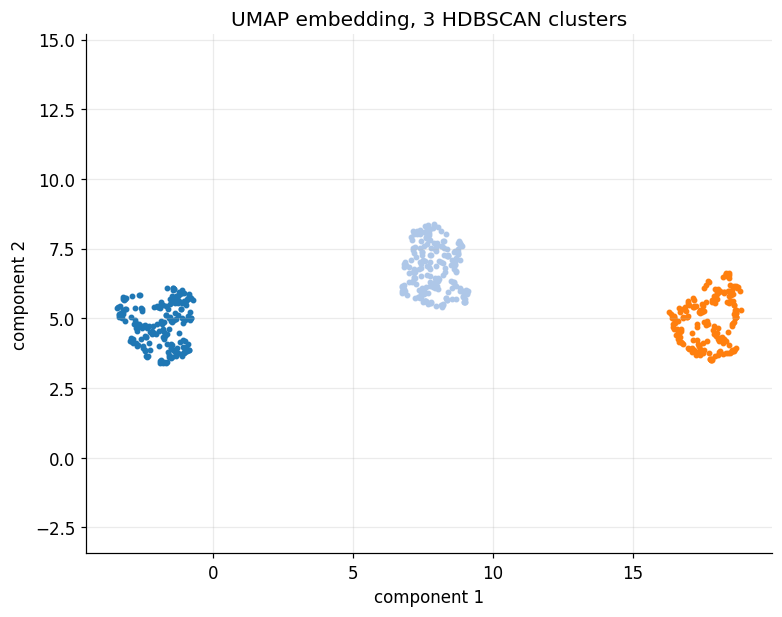

In [9]:
fig, ax = plt.subplots(figsize=(7.0, 5.5), constrained_layout=True)
sf.plot_embedding(result.embedding, result.labels, ax=ax)
ax.set_title(f"UMAP embedding, {result.n_clusters} HDBSCAN clusters")
fig.savefig(FIGURE_DIR / "02_pipeline_embedding.png")
plt.show()

### What lives on the result

`PipelineResult` is an immutable dataclass that holds every artefact
the pipeline produced. The most-used attributes:

In [10]:
print(f"embedding shape:      {result.embedding.shape}")
print(f"labels (unique):      {np.unique(result.labels).tolist()}")
print(f"persistence:          {[float(p) for p in result.persistence]}")
print(f"trustworthiness:      {result.trustworthiness:.4f}")
print(f"continuity:           {result.continuity:.4f}")
print(f"n outliers:           {int(np.sum(result.labels == -1))}")
print(f"flags (empty if OK):  {result.flags or '(none)'}")

embedding shape:      (600, 2)
labels (unique):      [0, 1, 2]
persistence:          [0.8485413303133978, 0.839407539391874, 0.821434580848333]
trustworthiness:      0.9665
continuity:           0.9662
n outliers:           0
flags (empty if OK):  ['Optuna best was reached 24 trials before the end of the 30-trial budget; consider halving n_trials on similar runs to save compute.']


## §4. The four core building blocks

The pipeline orchestrates four independent primitives. Each is also
a public function you can call directly, with the same kwargs.

### §4a. Manifold learning: `run_umap`, `run_tsne`, `run_pca`

All three live in `starfold.embedding` and are thin wrappers around
the standard implementations. Below we project the *standardised*
`X` with each, then compare their layouts side by side.

Note: `run_umap` does not standardise its input (the pipeline does
this via `StandardScaler` before calling it). For a fair side-by-side
we scale once and reuse.

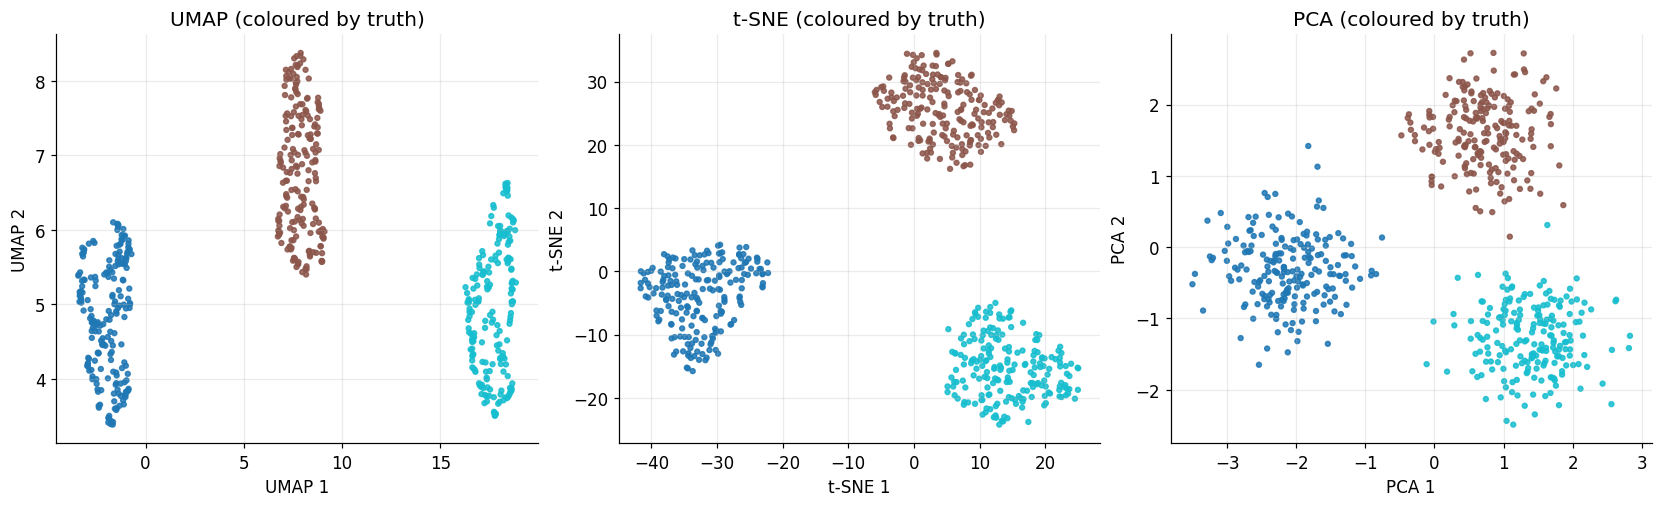

In [11]:
from sklearn.preprocessing import StandardScaler  # noqa: E402

X_scaled = StandardScaler().fit_transform(X)

emb_umap = sf.run_umap(X_scaled, n_neighbors=15, min_dist=0.0, n_epochs=200, random_state=0)
emb_tsne = sf.run_tsne(X_scaled, perplexity=30, n_iter=1_000, random_state=0)
emb_pca = sf.run_pca(X_scaled, n_components=2, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.5), constrained_layout=True)
for ax, (name, emb) in zip(axes, [("UMAP", emb_umap), ("t-SNE", emb_tsne), ("PCA", emb_pca)]):
    ax.scatter(emb[:, 0], emb[:, 1], c=y_truth, cmap="tab10", s=10, alpha=0.85)
    ax.set_xlabel(f"{name} 1"); ax.set_ylabel(f"{name} 2")
    ax.set_title(f"{name} (coloured by truth)")
fig.savefig(FIGURE_DIR / "03_embedding_comparison.png")
plt.show()

UMAP and t-SNE both separate the three components cleanly; PCA
captures the largest-variance direction but smears the second and
third clusters together. The pipeline uses UMAP because the paper
does, and because its parameter set lets us push points apart
(`min_dist=0.0`) in ways t-SNE cannot.

### Visualising two embeddings side-by-side

`plot_embedding_comparison` is the one-call utility version of the
loop above, intended for "did this knob change anything?" audits.

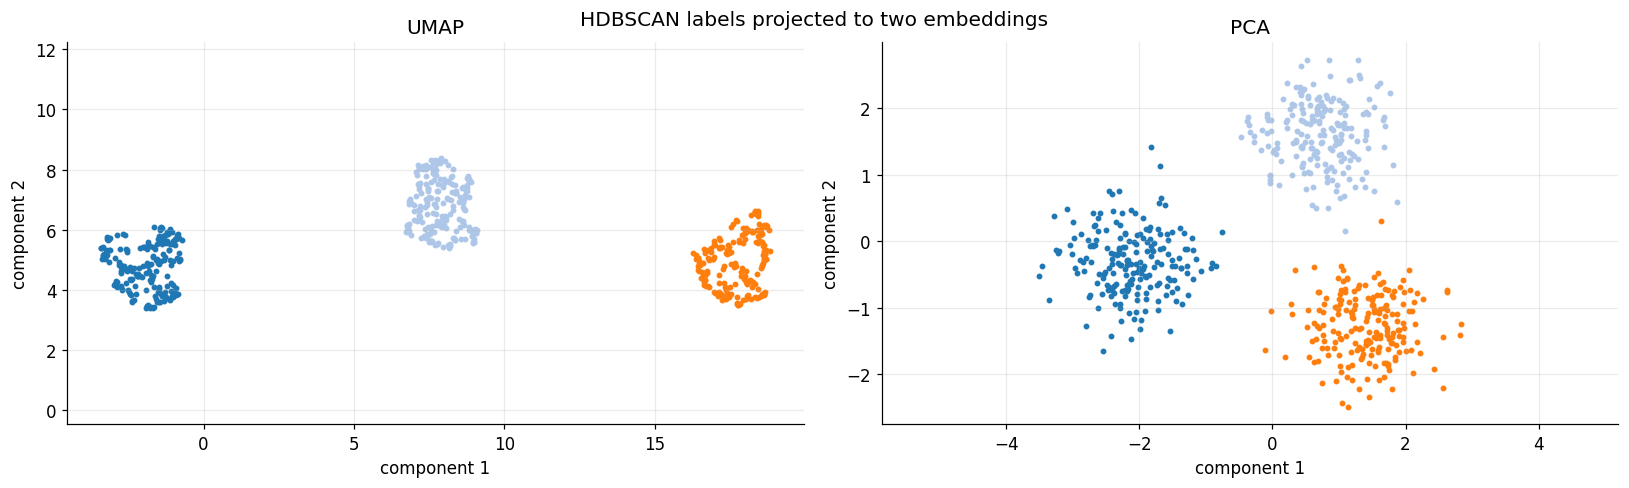

In [12]:
fig, _ = sf.plot_embedding_comparison(
    {"UMAP": emb_umap, "PCA": emb_pca},
    labels=result.labels,
)
fig.suptitle("HDBSCAN labels projected to two embeddings")
fig.savefig(FIGURE_DIR / "04_embedding_comparison_helper.png")
plt.show()

### §4b. Clustering: `run_hdbscan` at one config

`run_hdbscan(emb, min_cluster_size=...)` runs a single HDBSCAN fit
without any hyperparameter search. Useful when you have a domain
prior on cluster size, or to spot-check the Optuna pick.

In [13]:
hd = sf.run_hdbscan(emb_umap, min_cluster_size=30, min_samples=10)
print(f"clusters found:      {hd.n_clusters}")
print(f"persistence per cl.: {[float(p) for p in hd.cluster_persistence]}")
print(f"outliers:            {int(np.sum(hd.labels == -1))} / {hd.labels.size}")

clusters found:      3
persistence per cl.: [0.5739897150020585, 0.6053361090750078, 0.7024064295153847]
outliers:            0 / 600


### §4c. Hyperparameter search: `search_hdbscan`

When you do not know the right `min_cluster_size`, Optuna sweeps it
(plus `min_samples`, cluster selection method, epsilon, and alpha)
and maximises the sum of cluster persistences. The same routine
runs inside `UnsupervisedPipeline.fit`.

In [14]:
search = sf.search_hdbscan(
    emb_umap,
    n_trials=30,
    random_state=0,
)
print(f"best params: {search.best_params}")
print(f"best persistence sum: {search.best_persistence_sum:.4f}")
print(f"final fit: {search.hdbscan_result.n_clusters} clusters")

best params: {'min_cluster_size': 59, 'min_samples': 4, 'cluster_selection_method': 'eom', 'cluster_selection_epsilon': 0.3729667823044648, 'alpha': 1.4930644717695938}
best persistence sum: 2.6715
final fit: 3 clusters


### Auditing the search

`plot_optuna_history` shows the running-best objective over trials;
`plot_optuna_param_importance` runs fANOVA on the completed trials
to attribute objective variance to each hyperparameter.

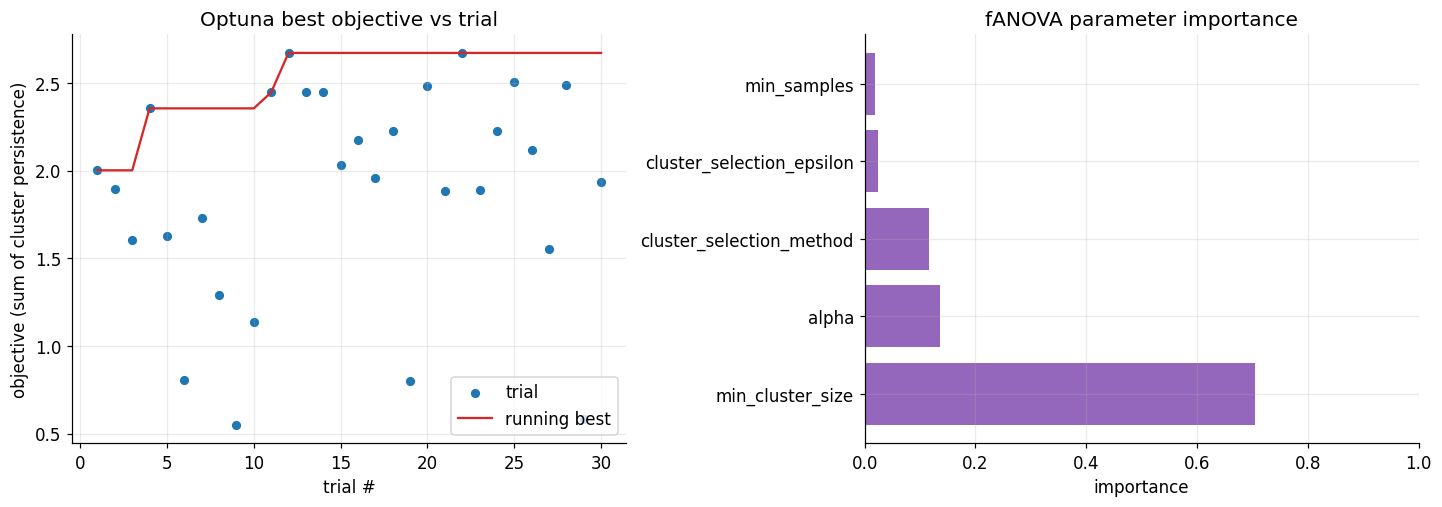

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.5), constrained_layout=True)
sf.plot_optuna_history(search.study, ax=axes[0])
axes[0].set_title("Optuna best objective vs trial")
sf.plot_optuna_param_importance(search.study, ax=axes[1])
axes[1].set_title("fANOVA parameter importance")
fig.savefig(FIGURE_DIR / "05_optuna_history_importance.png")
plt.show()

### The HDBSCAN condensed tree

`plot_condensed_tree` draws HDBSCAN's internal cluster-merge tree.
The y-axis is $\lambda$ (1 / density-merge distance); the x-axis is
the dendrogram layout. Tall, narrow branches are stable clusters;
short, flat patches are noise.

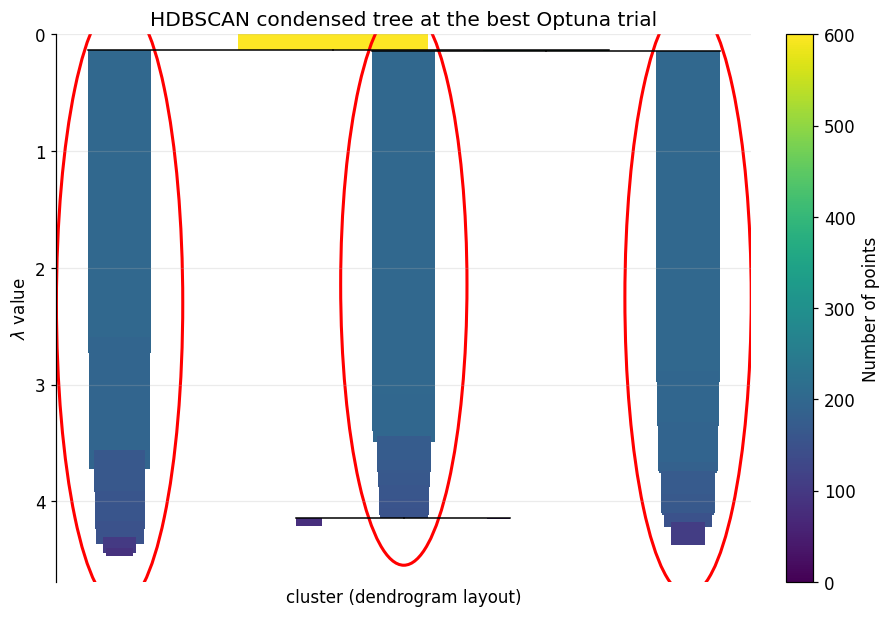

In [16]:
fig, ax = plt.subplots(figsize=(8.0, 5.5), constrained_layout=True)
sf.plot_condensed_tree(search.model, ax=ax)
ax.set_title("HDBSCAN condensed tree at the best Optuna trial")
fig.savefig(FIGURE_DIR / "06_condensed_tree.png")
plt.show()

### §4d. Embedding quality: trustworthiness and continuity

A trustworthy embedding does not invent neighbourhoods that are not
in the input; a continuous embedding does not destroy neighbourhoods
that are. Both range in $[0, 1]$ and ~0.9 or higher is the paper's
heuristic for a healthy fit.

`trustworthiness(X_high, X_low, k=...)` evaluates the
Venna & Kaski (2001) formula at a single $k$; the dual `continuity`
swaps the spaces. Both have vectorised `_curve` variants that compute
many $k$ values for the cost of one top-$k$ kNN query.

In [17]:
trust_single = sf.trustworthiness(X_scaled, result.embedding, k=15)
cont_single = sf.continuity(X_scaled, result.embedding, k=15)
print(f"T(k=15) = {trust_single:.4f}")
print(f"C(k=15) = {cont_single:.4f}")

T(k=15) = 0.9665
C(k=15) = 0.9662


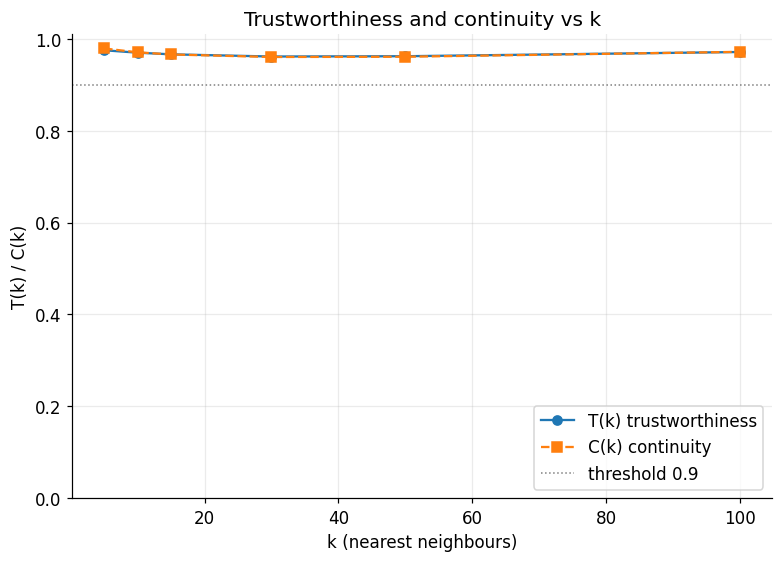

In [18]:
k_values = (5, 10, 15, 30, 50, 100)
trust = sf.trustworthiness_curve(X_scaled, result.embedding, k_values=k_values)
cont = sf.continuity_curve(X_scaled, result.embedding, k_values=k_values)

fig, ax = plt.subplots(figsize=(7.0, 5.0), constrained_layout=True)
sf.plot_trustworthiness_curve(trust, continuity_scores=cont, ax=ax)
ax.set_title("Trustworthiness and continuity vs k")
fig.savefig(FIGURE_DIR / "07_trustworthiness_continuity.png")
plt.show()

Both curves above 0.90 across the practical $k$ range means the
UMAP layout preserves local structure both ways.

## §5. Is the clustering real, or noise?

HDBSCAN finds at least one cluster on almost any input, including
pure Gaussian noise. Two questions therefore matter:

1. **Per-cluster.** Is this cluster's persistence higher than what
   noise typically produces?
2. **Per-run.** Is the run-level summary (cluster count, best Optuna
   objective, strongest persistence) jointly distinguishable from
   noise?

starfold answers both.

### §5a. `compute_noise_baseline`

Generates `n_realisations` independent Gaussian noise matrices of
the same shape as the data, runs UMAP + Optuna-HDBSCAN on each, and
records the maximum cluster persistence per realisation. The
99.7th percentile of those maxima is the 3σ threshold a real cluster
must clear to be flagged `significant`.

The full result is reused automatically by `pipeline.fit` when
`noise_baseline_kwargs` is set; we recompute here only to show the
raw call.

In [19]:
baseline = sf.compute_noise_baseline(
    n_samples=X.shape[0],
    n_features=X.shape[1],
    umap_kwargs=dict(n_neighbors=15, min_dist=0.0, n_epochs=200),
    n_realisations=15,
    per_realisation_trials=5,
    random_state=0,
)
print(f"99.7th-percentile threshold: {baseline.threshold:.4f}")
print(f"observed real-data persistences: "
      f"{[round(float(p), 3) for p in result.persistence]}")
print(f"clusters above threshold:     "
      f"{int(np.sum(result.significant))} / {len(result.significant)}")

99.7th-percentile threshold: 0.7569
observed real-data persistences: [0.849, 0.839, 0.821]
clusters above threshold:     3 / 3


### §5b. `compute_credibility` (the omnibus 3σ test)

`compute_credibility` aggregates three per-run scalars against
their noise nulls. Each scalar has a one-sided upper-tail empirical
p-value (Phipson & Smyth 2010 correction). The run "passes" at 3σ
when all three p-values clear `alpha=0.003`.

The pipeline already populated `result.credibility`; we call the
function directly to show what comes back.

In [20]:
report = sf.compute_credibility(
    n_clusters=result.n_clusters,
    best_objective=result.search.best_persistence_sum,
    max_persistence=float(result.persistence.max()),
    baseline=baseline,
    cluster_persistence=result.persistence,
)
print(report.summary())

credibility at alpha=0.003: FAIL
  n_clusters      obs=3  null-median=20  p=1.0000
  persistence_sum obs=2.5094  null-median=3.5342  p=0.6250
  max_persistence obs=0.8485  null-median=0.4885  p=0.0625
  per-cluster     3/3 clusters credible at alpha=0.003


Below: the per-cluster persistence overlaid on the noise null
pool, with markers showing the 50 % / 99.7 % / 99.97 % percentiles
(i.e. 0σ, 3σ, ~3.5σ).

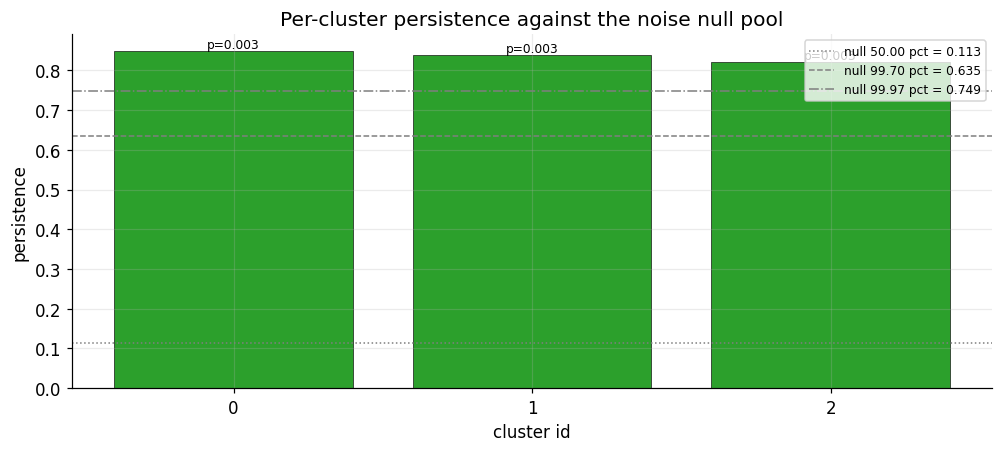

In [21]:
from starfold.plotting import plot_per_cluster_credibility  # noqa: E402

fig, ax = plt.subplots(figsize=(9.0, 4.0), constrained_layout=True)
plot_per_cluster_credibility(report, ax=ax)
ax.set_title("Per-cluster persistence against the noise null pool")
fig.savefig(FIGURE_DIR / "08_credibility.png")
plt.show()

## §6. Stability and robustness

Two cheap audits address "would this clustering hold up?".

### §6a. `chunked_silhouette`

Computes sklearn's silhouette coefficient *and* per-cluster
aggregates without ever materialising the N × N distance matrix.
Streams rows in blocks of `chunk_size`.

In [22]:
sil = sf.chunked_silhouette(result.embedding, result.labels, chunk_size=128)
print(f"overall silhouette: {sil.overall:.3f}")
print(f"per-cluster means:  {[round(float(s), 3) for s in sil.per_cluster]}")
print(f"cluster sizes:      {sil.cluster_sizes.tolist()}")

overall silhouette: 0.858
per-cluster means:  [0.862, 0.857, 0.856]
cluster sizes:      [200, 200, 200]


### §6b. `compute_subsample_stability`

Refits HDBSCAN on random subsamples of the 2-D embedding and
reports the Adjusted Rand Index (ARI) of each refit's labels
against the full-sample labels, plus the variance of the cluster
count across subsamples. A stable fit gives ARI close to 1 and a
small cluster-count spread.

In [23]:
stability = sf.compute_subsample_stability(
    embedding=result.embedding,
    reference_labels=result.labels,
    reference_persistence=result.persistence,
    min_cluster_size=int(result.best_params["min_cluster_size"]),
    min_samples=int(result.best_params["min_samples"]),
    cluster_selection_method=str(result.best_params.get("cluster_selection_method", "eom")),
    n_subsamples=10,
    subsample_fraction=0.8,
    random_state=0,
)
print(f"ARI distribution (n={len(stability.ari)}): "
      f"min={stability.ari.min():.3f}, median={float(np.median(stability.ari)):.3f}, "
      f"max={stability.ari.max():.3f}")
print(f"n_clusters across subsamples: {stability.n_clusters.tolist()}")

ARI distribution (n=10): min=1.000, median=1.000, max=1.000
n_clusters across subsamples: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]


## §7. Refining the clustering

After the run is trusted, two methods let you act on the result.

### §7a. `result.suggest_merges()`

Flags pairs of clusters where the HDBSCAN condensed tree (density
evidence) *and* the 2-D embedding geometry (centroid gap relative
to intra-cluster dispersion) both agree the pair should be one.
Pairs where the two heuristics disagree are kept apart on purpose.

In [24]:
merges = result.suggest_merges()
print(f"{len(merges)} candidate pairs evaluated")
recommended = [m for m in merges if m.recommended]
if recommended:
    print(f"{len(recommended)} pair(s) where density AND geometry agree:")
    for m in recommended[:3]:
        print(f"  cluster {m.cluster_i} <-> cluster {m.cluster_j}: "
              f"cohesion ratio {m.cohesion_ratio:.2f}, "
              f"gap ratio {m.gap_ratio:.2f}")
else:
    print("no recommended merges (the HDBSCAN split is internally consistent)")

3 candidate pairs evaluated
no recommended merges (the HDBSCAN split is internally consistent)


### §7b. `result.refit_subcluster`

Drops back into the full pipeline (UMAP, Optuna, noise baseline,
credibility) on the subset `X[result.labels == cluster_id]`. The
paper's two-run workflow expressed as one method call.

In [25]:
sub_result = result.refit_subcluster(X, cluster_id=int(np.unique(result.labels[result.labels >= 0])[0]))
print(sub_result.summary())

!! diagnostic flags
--------------------------------
- LOW TRUSTWORTHINESS: T(k)=0.897 < 0.90. The 2-D embedding does not preserve local neighbourhoods well, so downstream cluster labels should be interpreted with care. Consider raising n_neighbors or n_epochs, or providing features with less redundancy.
- NOISE-CONSISTENT: no cluster beats the noise baseline threshold (0.711). The fit may be indistinguishable from structureless noise at the requested percentile; treat cluster assignments as tentative.
- Optuna best was reached 24 trials before the end of the 30-trial budget; consider halving n_trials on similar runs to save compute.

starfold pipeline result
--------------------------------
n_samples        200
n_clusters       13
n_outliers       28  (14.0%)
trustworthiness  0.8967
continuity       0.8670
objective        persistence_sum
best_params      {'min_cluster_size': 8, 'min_samples': 1, 'cluster_selection_method': 'leaf', 'cluster_selection_epsilon': 0.2858928040329025, 'alp

/home/aneitzel/projects/starfold/src/starfold/pipeline.py:466: UserWarning: LOW TRUSTWORTHINESS: T(k)=0.897 < 0.90. The 2-D embedding does not preserve local neighbourhoods well, so downstream cluster labels should be interpreted with care. Consider raising n_neighbors or n_epochs, or providing features with less redundancy.
  return UnsupervisedPipeline(**kwargs).fit(x[mask])
/home/aneitzel/projects/starfold/src/starfold/pipeline.py:466: UserWarning: NOISE-CONSISTENT: no cluster beats the noise baseline threshold (0.711). The fit may be indistinguishable from structureless noise at the requested percentile; treat cluster assignments as tentative.
  return UnsupervisedPipeline(**kwargs).fit(x[mask])
/home/aneitzel/projects/starfold/src/starfold/pipeline.py:466: UserWarning: Optuna best was reached 24 trials before the end of the 30-trial budget; consider halving n_trials on similar runs to save compute.
  return UnsupervisedPipeline(**kwargs).fit(x[mask])


The sub-cluster is small (we picked a single component of three),
so a noise baseline is unlikely to be confidently rejectable; the
point here is the *mechanism*, not a fresh significance verdict.

## §8. Input uncertainty

When the feature matrix carries per-feature 1σ error bars, two
modes are available.

### §8a. Post-hoc propagation

`result.propagate_uncertainty(X, sigma)` freezes the clean fit and
Monte Carlos the input through the trained UMAP and HDBSCAN models
(via `hdbscan.approximate_predict`). Each sample gets a
membership-probability vector and an instability scalar.

In [26]:
sigma = 0.10  # isotropic, units of the original feature scale
propagation = result.propagate_uncertainty(X, sigma=sigma, n_draws=40, random_state=0)
print(f"instability summary: "
      f"min={propagation.instability.min():.3f}, "
      f"median={float(np.median(propagation.instability)):.3f}, "
      f"max={propagation.instability.max():.3f}")
print(f"confident (instability < 0.10): "
      f"{int(np.sum(propagation.instability < 0.10))} / {len(propagation.instability)}")

instability summary: min=0.000, median=0.000, max=0.000
confident (instability < 0.10): 600 / 600


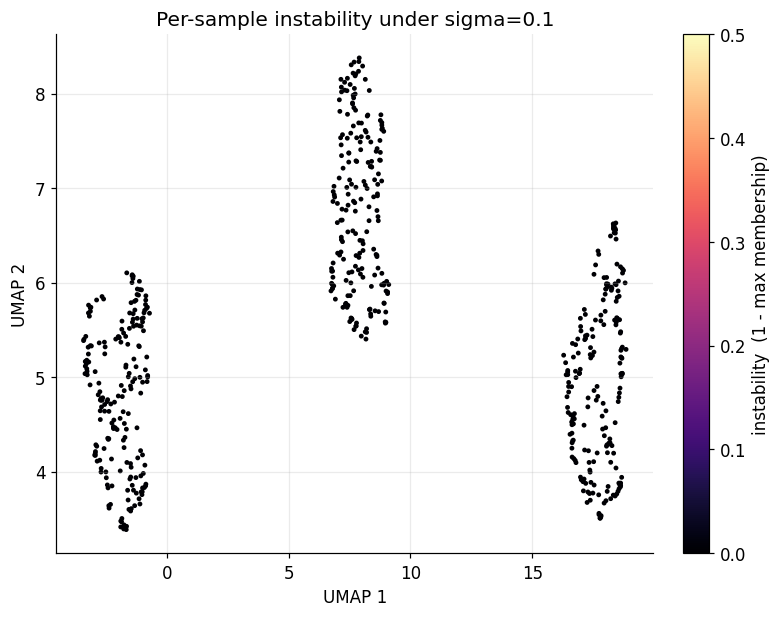

In [27]:
fig, ax = plt.subplots(figsize=(7.0, 5.5), constrained_layout=True)
sf.plot_uncertainty_map(result.embedding, propagation, ax=ax)
ax.set_title(f"Per-sample instability under sigma={sigma}")
fig.savefig(FIGURE_DIR / "09_uncertainty_map.png")
plt.show()

### §8b. Uncertainty-aware fit

`pipeline.fit_with_uncertainty(X, sigma, n_replicas)` feeds an
augmented matrix (clean samples + Gaussian replicas) through the
full pipeline. UMAP and HDBSCAN therefore see the spread itself, so
the noise baseline and credibility test are computed against the
enlarged sample.

In [28]:
aware = pipeline.fit_with_uncertainty(X, sigma=sigma, n_replicas=3)
print(f"aware-fit clusters: {aware.augmented_result.n_clusters} "
      f"(clean-fit was {result.n_clusters})")
print(f"aware-fit trustworthiness: {aware.augmented_result.trustworthiness:.4f}")

aware-fit clusters: 119 (clean-fit was 3)
aware-fit trustworthiness: 0.9931


Mode A vs Mode B answer different questions: A is "given the
clustering I trust, how robust is each sample's assignment?";
B is "what clustering does the data support when its uncertainty
is part of the fit?".

## §9. Save and reload

`result.save(directory)` writes the embedding, labels, persistence,
trustworthiness, the fitted scaler and reducer, the run config, and
(when present) the noise-baseline summary plus credibility report.
`sf.load_pipeline_result(directory)` returns the same content as a
dict; the Optuna study is not rehydrated (see the docstring).

In [29]:
import tempfile  # noqa: E402

with tempfile.TemporaryDirectory() as tmp:
    run_dir = Path(tmp) / "walkthrough_run"
    saved_path = result.save(run_dir)
    files = sorted(p.name for p in saved_path.iterdir())
    print(f"saved {len(files)} files: {files}")
    loaded = sf.load_pipeline_result(run_dir)

assert np.array_equal(loaded["labels"], result.labels)
assert np.allclose(loaded["embedding"], result.embedding, atol=0.0)
print("round-trip OK: labels and embedding are bit-identical")

saved 2 files: ['arrays.npz', 'meta.json']
round-trip OK: labels and embedding are bit-identical


`save_pipeline_result(result, directory)` is the free-function form
of `result.save(directory)`; either signature works.

## §10. The two one-line dashboards

Every diagnostic above can be assembled into two single-call audit
panels. They are not magic — each panel is one of the helpers we
already met — but they are the convenient form when you want to
look at one run quickly.

### Tuning dashboard (8 panels)

Optuna history, two Pareto fronts, the (MCS, MS) landscape, the
granularity-stability trade-off, parallel coordinates, condensed
tree, and fANOVA importance. A star in every panel marks the
selected trial.

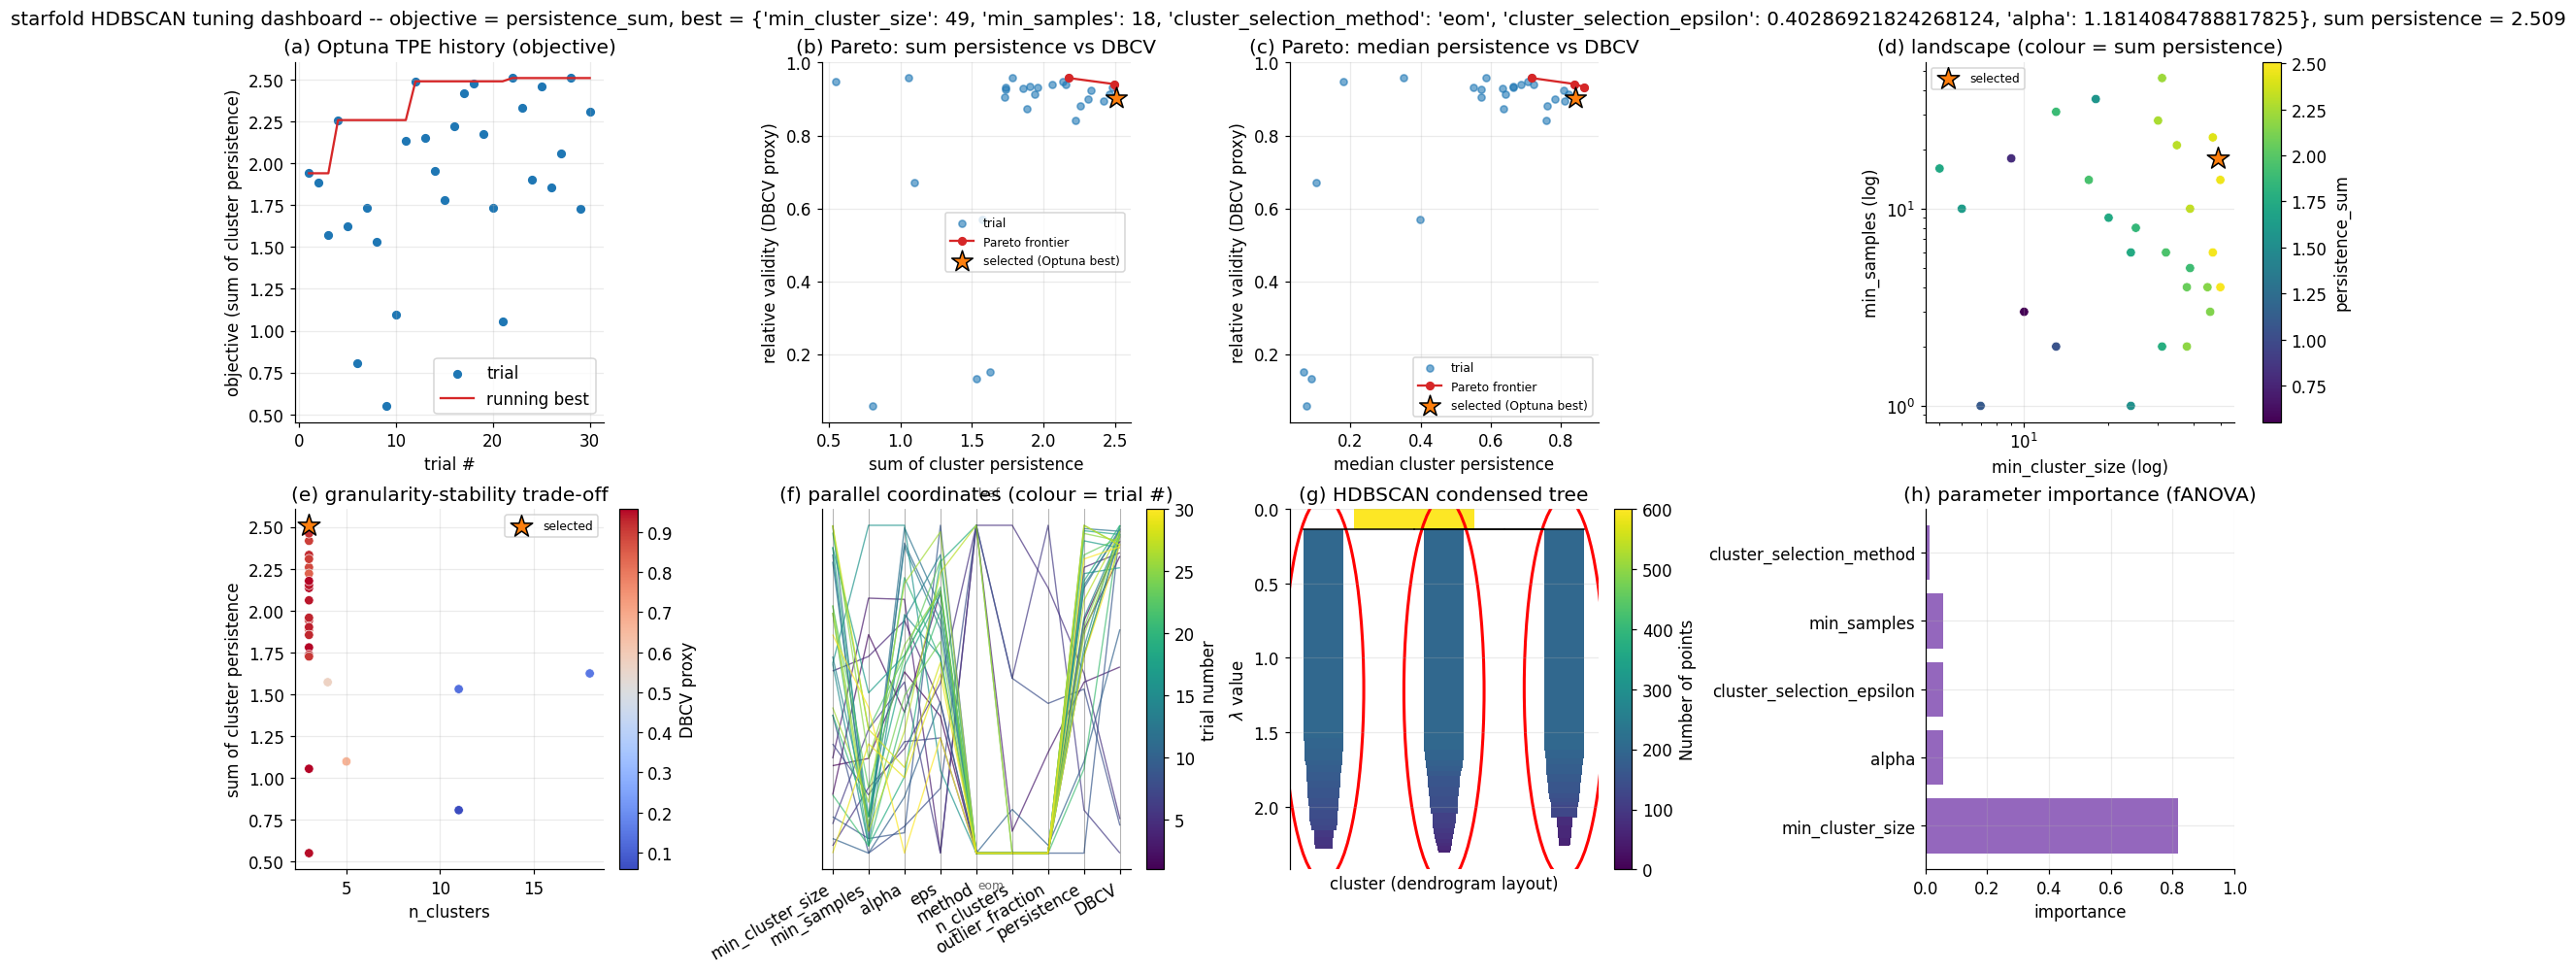

In [30]:
fig = result.plot_tuning_dashboard(figsize=(20.0, 9.0))
fig.savefig(FIGURE_DIR / "10_tuning_dashboard.png")
plt.show()

### Quality dashboard (6 panels)

Embedding coloured by label, by membership probability, by
instability, plus fANOVA importance, the subsample-stability
distribution, and the trustworthiness/continuity curves. This is
the "is this result reproducible?" view.

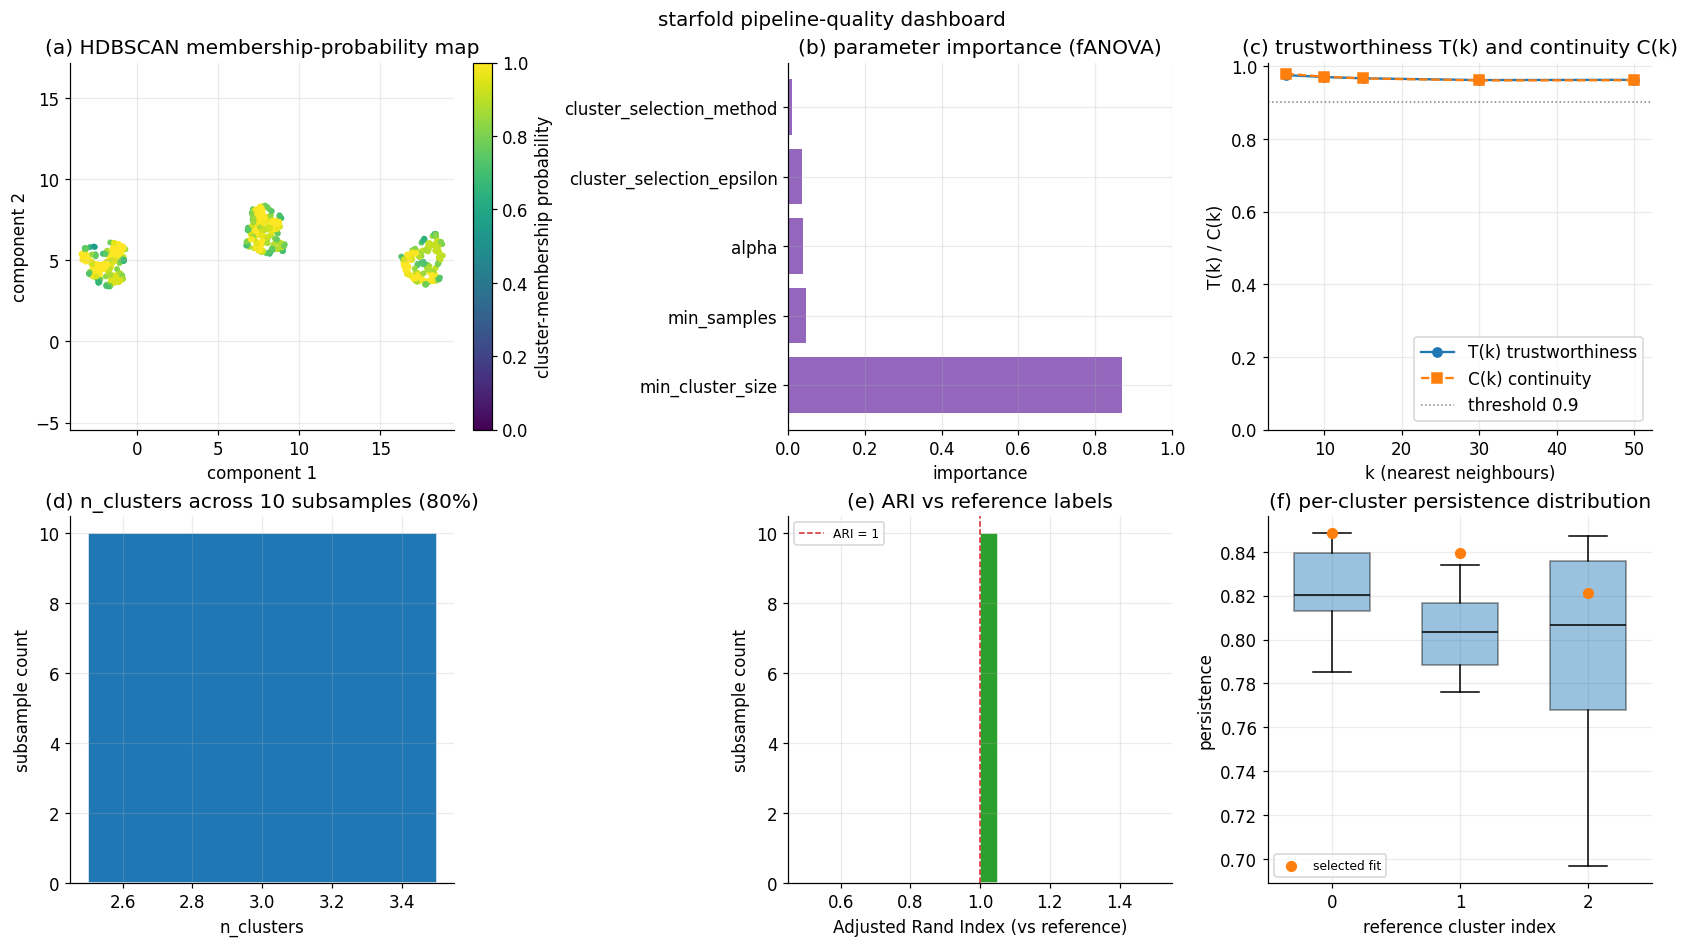

In [31]:
fig = result.plot_quality_dashboard(
    X,
    n_subsamples=10,
    subsample_fraction=0.8,
    k_values=(5, 10, 15, 30, 50),
    figsize=(15.0, 8.5),
    random_state=0,
)
fig.savefig(FIGURE_DIR / "11_quality_dashboard.png")
plt.show()

## §11. Where to next

Every public function in `starfold.__all__` has been demonstrated
in this notebook. For deeper coverage of a specific topic:

* **[`tutorial_01_quickstart.ipynb`](tutorial_01_quickstart.ipynb)**
  — a stripped-down end-to-end pass on a topologically non-trivial
  synthetic dataset (8-torus chain).
* **[`tutorial_02_validation.ipynb`](tutorial_02_validation.ipynb)**
  — noise baseline and credibility test at production budgets;
  tuning and quality dashboards explained panel by panel.
* **[`tutorial_03_advanced.ipynb`](tutorial_03_advanced.ipynb)**
  — refinement workflow in detail: silhouette, merge recommender,
  sub-cluster refit, and both uncertainty modes side-by-side.
* **[`tutorial_04_astronomy.ipynb`](tutorial_04_astronomy.ipynb)**
  — a real-data case study on 9 242 Milky Way stars from APOGEE
  DR19 and Gaia DR3, bundled as a 0.5 MB parquet so no survey
  download is needed.

For the methodology background, `docs/methodology.md` rewrites
paper §3 (the core pipeline) and §§6-9 (the extensions) for
non-astronomers. For every place where the paper is silent on a
default, see `docs/design_decisions.md`.